# Edge IIoT - Data Cleaning for Machine Learning

This phase focuses on refining the raw dataset into a structured format suitable for subsequent modeling. The following principles guide this process:
- The cleaning procedures described are applicable to both Binary and Multiclass classification tasks. Note that specific features may be selectively enabled or disabled depending on the classification objective and restrictions.
- In this study, "Cleaning" includes basic feature transformations that can be performed during the initial packet capture (PCAP) extraction or via simple logic. Complex, model-dependent transformations (such as scaling, normalization, or advanced encoding) are reserved for the Preprocessing phase.
- The cleaning logic is informed by the following kaggle notebooks:
    - [Edge-IIoTset Pre-Processing](https://www.kaggle.com/code/mohamedamineferrag/edge-iiotset-pre-processing) by Mohamed Amine Ferrag
    - [Predict Attack and Attack Type](https://www.kaggle.com/code/waleedgul/predict-attack-and-attack-type#Irrelevant-Columns-for-IoT-Attack-Detection) by Waleed Gul

In [295]:
LOAD_LARGE_CSV = False # Set to True if you want to load the DNN file instead of the ML one.

## 0 - Obtaining data 

In [296]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['raw_path']}\n")

if LOAD_LARGE_CSV:
    filename = "DNN-EdgeIIoT-dataset"
else:
    filename = "ML-EdgeIIoT-dataset"

csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / f"{filename}.csv"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_csv(csv_path, low_memory=False)

print(f"\nDataset loaded with shape: {df.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv

Loading dataset... (This may take a while)

Dataset loaded with shape: (157800, 63)


In [297]:
df.loc[0, (df != '0').any(axis=0)]

frame.time                      6.0
ip.src_host           192.168.0.152
ip.dst_host                     0.0
arp.dst.proto_ipv4              0.0
arp.opcode                      0.0
                          ...      
mbtcp.len                       0.0
mbtcp.trans_id                  0.0
mbtcp.unit_id                   0.0
Attack_label                      1
Attack_type                    MITM
Name: 0, Length: 63, dtype: object

In [298]:
print("Column count:", len(df.columns))
print("\n--- Columns ---\n", df.columns)

Column count: 63

--- Columns ---
 Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.co

In [299]:
packet_types = []
for col in df.columns:
    if '.' in col:
        proto = col.split('.')[0]
        if proto not in packet_types:
            packet_types.append(proto)

print(f"\nPacket types: {packet_types}\n")


Packet types: ['frame', 'ip', 'arp', 'icmp', 'http', 'tcp', 'udp', 'dns', 'mqtt', 'mbtcp']



## 1 - Initial Exploration

### 1.1 - Data order

1. The column `frame.time` logs the precise arrival timestamp of the network packet at the Frame layer.
2. The dataset is currently ordered according to packet processing sequences rather than raw arrival times. As this processing sequence represents the real operational logic of the system, this order shall be preserved for accurate temporal modeling.

In [300]:
df['frame.time']

0                               6.0
1                               6.0
2                               6.0
3                               6.0
4                               6.0
                    ...            
157795     2021 23:24:32.698981000 
157796     2021 23:24:32.699354000 
157797     2021 23:24:32.719931000 
157798     2021 23:24:32.752054000 
157799     2021 23:24:32.780376000 
Name: frame.time, Length: 157800, dtype: str

In [301]:
df['frame.time'] = df['frame.time'].str.strip()
converted_times = pd.to_datetime(df['frame.time'], format="%Y %H:%M:%S.%f", exact=False, errors='coerce')

noisy_mask = converted_times.isna()
noisy_count = noisy_mask.sum()
print(f"Number noisy frame.times: {noisy_count}")
print(f"Percentage: {(noisy_count / len(df)) * 100:.4f}%\n")

Number noisy frame.times: 15712
Percentage: 9.9569%



In [302]:
df['frame.time'] = converted_times
df = df.dropna(subset=['frame.time'])

In [303]:
df['frame.time'].describe()

count                           142088
mean     2021-01-01 19:05:07.278125568
min         2021-01-01 00:00:01.163427
25%      2021-01-01 17:55:28.909851904
50%      2021-01-01 19:26:07.706263040
75%      2021-01-01 21:42:41.620859136
max         2021-01-01 23:59:59.358821
Name: frame.time, dtype: object

### 1.2 -  Protocol

In [304]:
df['proto'] = 'noinfo'

#### 1.2.1 - ARP and ICMP

In [305]:
df.loc[df['arp.opcode'] != 0, 'proto'] = 'ARP'
df['proto'].value_counts()

proto
noinfo    140514
ARP         1574
Name: count, dtype: int64

In [306]:
df.loc[(df['icmp.checksum'] != 0) | (df['icmp.seq_le'] != 0) | (df['icmp.transmit_timestamp'] != 0), 'proto'] = 'ICMP'
df['proto'].value_counts()

proto
noinfo    125844
ICMP       14670
ARP         1574
Name: count, dtype: int64

#### 1.2.2 -  TCP and UDP

In [307]:
df.loc[(~df['tcp.srcport'].isin(['0.0', '0'])) | (~df['tcp.srcport'].isin(['0.0', '0'])), 'proto'] = 'TCP'
df['proto'].value_counts()

proto
TCP       123880
ICMP       14670
noinfo      1964
ARP         1574
Name: count, dtype: int64

In [308]:
df.loc[(df['udp.port'] != 0), 'proto'] = 'UDP'
df['proto'].value_counts()

proto
TCP       123880
ICMP       14670
noinfo      1926
ARP         1574
UDP           38
Name: count, dtype: int64

#### 1.2.3 -  HTTP, DNS, MQTT and MBTCP

In [309]:
df.loc[~df['http.request.method'].isin(['0.0', '0']) , 'proto'] = 'HTTP'
df['proto'].value_counts()

proto
TCP       116684
ICMP       14670
HTTP        7196
noinfo      1926
ARP         1574
UDP           38
Name: count, dtype: int64

In [310]:
df.loc[df['dns.qry.qu'] != 0, 'proto'] = 'DNS'
df['proto'].value_counts()

proto
TCP       116684
ICMP       14670
HTTP        7196
noinfo      1926
ARP         1574
DNS           29
UDP            9
Name: count, dtype: int64

In [311]:
df.loc[(df['mqtt.msgtype'] != 0), 'proto'] = 'MQTT'
df['proto'].value_counts()

proto
TCP       111621
ICMP       14670
HTTP        7196
MQTT        5063
noinfo      1926
ARP         1574
DNS           29
UDP            9
Name: count, dtype: int64

In [312]:
df.loc[(df['tcp.srcport'] == 502) | (df['tcp.dstport'] == 502), 'proto'] = 'MBTCP'
df['proto'].value_counts()

proto
TCP       111602
ICMP       14670
HTTP        7196
MQTT        5063
noinfo      1926
ARP         1574
DNS           29
MBTCP         19
UDP            9
Name: count, dtype: int64

#### 1.2.4 -  No info Exploration

In [313]:
df_noinfo = df[df['proto'] == 'noinfo']

for index, row in df_noinfo.iterrows():
    cols = []

    for col, val in row.items():
        if col in ['frame.time', 'proto', 'ip.src_host', 'ip.dst_host',  'Attack_type', 'Attack_label']:
            continue
        if val not in [0, '0', '0.0', 0.0]:
            cols.append(col)
        
        if len(cols) > 0:
            print(f"--- {index} ---")
            print(cols)

In [314]:
pd.crosstab(df_noinfo['ip.src_host'], df_noinfo['Attack_type'])

Attack_type,Backdoor,DDoS_HTTP,DDoS_ICMP,Fingerprinting,Normal,Password,Port_Scanning,Ransomware,SQL_injection,Uploading,Vulnerability_scanner,XSS
ip.src_host,,,,,,,,,,,,
0,152,1,0,50,55,8,307,534,11,7,9,317
0.0.0.0,11,0,1,6,4,0,31,65,1,0,0,31
192.168.0.128,40,0,0,12,11,1,43,130,2,2,1,83


In [315]:
pd.crosstab(df_noinfo['ip.dst_host'], df_noinfo['Attack_type'])

Attack_type,Backdoor,DDoS_HTTP,DDoS_ICMP,Fingerprinting,Normal,Password,Port_Scanning,Ransomware,SQL_injection,Uploading,Vulnerability_scanner,XSS
ip.dst_host,,,,,,,,,,,,
0,152,1,0,50,55,8,307,534,11,7,9,317
224.0.0.1,11,0,1,6,4,0,31,65,1,0,0,31
224.0.0.251,18,0,0,6,11,1,43,65,0,2,1,40
224.0.0.252,22,0,0,6,0,0,0,65,2,0,0,43


We cannot identify empty packets so they will be dropped.

In [316]:
df.drop(df_noinfo.index, inplace=True)

## 2 - Treating Columns

In [317]:
def print_unique_values(df, column_names):
    for col in column_names:
        unique_values = df[col].unique()
        print(f"\n--- {col} --- \n{unique_values}\n")

def find_packet_type_columns(df, packet_type):
    return [col for col in df.columns if col.startswith(f'{packet_type}.')]

### 2.01 - Frame

In [318]:
cols = find_packet_type_columns(df, 'frame')
print("\n>>> FRAME COLUMNS <<<\n", cols)


>>> FRAME COLUMNS <<<
 ['frame.time']


#### 2.01.01 - `frame.time`
- **Definition:** Logs the precise arrival timestamp of the network packet at the Frame layer.
- **Treatment:** Transformed.
- **Reason:** Timing alone doesn’t indicate malicious behavior but order and difference does (DoS Attacks).

In [319]:
flow_columns = ['ip.src_host', 'ip.dst_host','proto']
df['frame.time.order'] = df.groupby(flow_columns).cumcount() + 1

df['frame.time.order'].describe()

count    140162.000000
mean      12781.960360
std       13066.775268
min           1.000000
25%        1110.000000
50%        7031.000000
75%       23579.750000
max       42041.000000
Name: frame.time.order, dtype: float64

In [320]:
df['frame.time.delta'] = df.groupby(flow_columns)['frame.time'].diff()
df['frame.time.delta'] = df['frame.time.delta'].dt.total_seconds()
df['frame.time.delta'] = df['frame.time.delta'].fillna(0)

df['frame.time.delta'].describe()

count    140162.000000
mean         -0.743157
std         813.491287
min      -86398.114095
25%           0.002235
50%           0.139107
75%           2.029151
max       81895.715094
Name: frame.time.delta, dtype: float64

In [321]:
df.drop(columns=['frame.time'], inplace=True)

### 2.02 - IP (Internet Protocol)

In [322]:
cols = find_packet_type_columns(df, 'ip')
print("\n>>> IP COLUMNS <<<\n", cols)


>>> IP COLUMNS <<<
 ['ip.src_host', 'ip.dst_host']


#### 2.02.01 - `ip.src_host` and `ip.dst_host`

- **Definition**: Source and destination IPv4 addresses of the packet.
- **Treatment**: Transformed.
- **Reason**: To prevent the model from memorizing environment-specific addresses it is transformed into `Public`, `Private` or `Reserved`.

In [323]:
print_unique_values(df, ["ip.src_host"])


--- ip.src_host --- 
<StringArray>
[  '192.168.0.170',   '192.168.0.128',               '0',   '216.58.198.74',
    '231.1.226.56', '122.211.209.241',  '214.38.141.227',    '25.32.161.26',
    '1.71.192.140', '207.185.119.243',
 ...
     '5.78.209.48',   '157.210.125.7',    '221.40.206.7',    '95.70.146.72',
    '5.153.51.123',   '193.152.82.43',    '253.52.1.213',  '107.155.221.49',
   '77.242.58.228',   '149.40.90.151']
Length: 17686, dtype: str



In [324]:
df[df['Attack_label'] == 1][['ip.src_host', 'ip.dst_host']].value_counts()

ip.src_host     ip.dst_host  
192.168.0.170   192.168.0.128    47686
192.168.0.128   192.168.0.170    42290
0               0                 1532
192.168.0.128   172.217.19.42       19
172.217.19.42   192.168.0.128       17
                                 ...  
193.152.82.43   192.168.0.128        1
253.52.1.213    192.168.0.128        1
107.155.221.49  192.168.0.128        1
77.242.58.228   192.168.0.128        1
149.40.90.151   192.168.0.128        1
Name: count, Length: 24351, dtype: int64

In [325]:
import ipaddress

def categorize_ip(ip_str):
    try:
        if ip_str in ['0', '0.0', 0]:
            return 'Malformed'
            
        ip = ipaddress.ip_address(ip_str)
        if ip.is_private:
            return 'Private'
        elif ip.is_multicast or ip.is_reserved:
            return 'Reserved'
        else:
            return 'Public'
    except ValueError:
        return 'Invalid'
    
df['ip.src_category'] = df['ip.src_host'].apply(categorize_ip)
df['ip.dst_category'] = df['ip.dst_host'].apply(categorize_ip)

In [326]:
df[df['Attack_label'] == 1][['ip.src_category', 'ip.dst_category']].value_counts()

ip.src_category  ip.dst_category
Private          Private            92010
Public           Private            15033
Private          Public              6121
Malformed        Malformed           1532
Reserved         Private             1235
Name: count, dtype: int64

In [327]:
df[df['Attack_label'] == 0][['ip.src_category', 'ip.dst_category']].value_counts()

ip.src_category  ip.dst_category
Private          Private            20087
Malformed        Malformed           4135
Public           Private                4
Private          Public                 3
                 Reserved               2
Name: count, dtype: int64

In [328]:
df = pd.get_dummies(df, columns=['ip.src_category', 'ip.dst_category'], dtype=int)

In [329]:
df.drop(columns=['ip.src_host', 'ip.dst_host'], inplace=True)
print("\nDropped 'ip.src_host' column:", not 'ip.src_host' in df.columns)
print("\nDropped 'ip.dst_host' column:", not 'ip.dst_host' in df.columns)


Dropped 'ip.src_host' column: True

Dropped 'ip.dst_host' column: True


### 2.03 - ARP (Address Resolution Protocol)

In [330]:
cols = find_packet_type_columns(df, 'arp')
print("\n>>> ARP COLUMNS <<<\n", cols)


>>> ARP COLUMNS <<<
 ['arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4']


#### 2.03.01 - `arp.src.proto_ipv4` and `arp.dst.proto_ipv4`

- **Definition**: Represents the sender and target IPv4 addresses within the ARP header.
- **Treatment**: Dropped.
- **Reason**: Removal prevents the model from memorizing environment-specific addresses.

In [331]:
df.drop(columns=['arp.dst.proto_ipv4', 'arp.src.proto_ipv4'], inplace=True)
print("\nDropped 'arp.dst.proto_ipv4' column:", not 'arp.dst.proto_ipv4' in df.columns)
print("\nDropped 'arp.src.proto_ipv4' column:", not 'arp.src.proto_ipv4' in df.columns)


Dropped 'arp.dst.proto_ipv4' column: True

Dropped 'arp.src.proto_ipv4' column: True


#### 2.03.02 - `arp.hw.size`

- **Definition**: Specifies the length (in bytes) of the hardware address.
- **Treatment**: Dropped.
- **Reason**: Redundancy and zero variance. The value remains constant (`6`) for all valid ARP packets, resulting in high collinearity with arp.opcode.

In [332]:
print_unique_values(df, ['arp.hw.size'])


--- arp.hw.size --- 
[0. 6.]



In [333]:
print(
    "\n--- Count hw.size if arp.code != 0 ---\n",
    df[df['arp.opcode'] != 0.]['arp.hw.size'].value_counts(),
    "\n\n\n--- Correlation opcode to hw.size ---\n",
    f"{df[['arp.opcode', 'arp.hw.size']].corr()['arp.hw.size']['arp.opcode']:0.4f}"
)


--- Count hw.size if arp.code != 0 ---
 arp.hw.size
6.0    1574
Name: count, dtype: int64 


--- Correlation opcode to hw.size ---
 0.9441


In [334]:
df.drop(columns=['arp.hw.size'], inplace=True)
print("\nDropped 'arp.hw.size' column:", not 'arp.hw.size' in df.columns)


Dropped 'arp.hw.size' column: True


#### 2.03.03 - `arp.opcode`

- **Definition**: Type of ARP message (`0` = No ARP, `1` = ARP Request or `2` = ARP Reply).
- **Treatment**: Retained / Binarization. Transformed into two binary features: `arp.opcode_request` and `arp.opcode_reply`.
- **Reason**: The opcode is a nominal categorical variable, not an ordinal one.

> NOTE
> 
> Non-ARP packets (original value 0) result in both new binary features being set to 0.

In [335]:
print_unique_values(df, ['arp.opcode'])


--- arp.opcode --- 
[0. 1. 2.]



In [336]:
df['arp.opcode_request'] = (df['arp.opcode'] == 1).astype(int)
df['arp.opcode_reply'] = (df['arp.opcode'] == 2).astype(int)

print(df[['arp.opcode_request', 'arp.opcode_reply']].sum())

arp.opcode_request    908
arp.opcode_reply      666
dtype: int64


In [337]:
df.drop(columns=['arp.opcode'], inplace=True)
print("\nDropped 'arp.opcode' column:", not 'arp.opcode' in df.columns)


Dropped 'arp.opcode' column: True


### 2.04 - ICMP (Internet Control Message Protocol)

In [338]:
cols = find_packet_type_columns(df, 'icmp')
print("\n>>> ICMP COLUMNS <<<\n", cols)


>>> ICMP COLUMNS <<<
 ['icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused']


#### 2.04.01 - `icmp.checksum`

- **Definition**: A 16-bit field used for error-checking the ICMP header and data to ensure integrity.
- **Treatment**: Dropped.
- **Reason:** Checksums are transient values computed dynamically per packet.

In [339]:
print_unique_values(df, ['icmp.checksum'])


--- icmp.checksum --- 
[11938. 13986.  1418. ... 45657. 57686.  9555.]



In [340]:
df.drop(columns=['icmp.checksum'], inplace=True)
print("\nDropped 'icmp.checksum' column:", not 'icmp.checksum' in df.columns)


Dropped 'icmp.checksum' column: True


#### 2.04.02 - `icmp.seq_le`

- **Definition**: The Sequence Number (Little Endian) used to pair Echo Requests with corresponding Echo Replies.
- **Treatment**: Retained
- **Reason:** Discontinuities, high-frequency increments, or non-sequential jumps in sequence numbers are primary indicators of ICMP flooding (DoS) or data exfiltration via covert tunneling.

In [341]:
print_unique_values(df, ['icmp.seq_le'])


--- icmp.seq_le --- 
[    0.   256.  1863. ... 40702. 41423. 42379.]



#### 2.04.03 - `icmp.transmit_timestamp`

- **Definition**: A timestamp indicating when the sender last interacted with the message before transmission.
- **Treatment**: Dropped.
- **Reason:** Timing synchronization data is highly host-specific. ML models will model only spacial features.

In [342]:
df.drop(columns=['icmp.transmit_timestamp'], inplace=True)
print("\nDropped 'icmp.transmit_timestamp' column:", not 'icmp.transmit_timestamp' in df.columns)


Dropped 'icmp.transmit_timestamp' column: True


#### 2.04.04 - `icmp.unused`

- **Definition**: A 4-byte reserved field that is mandated to be set to zero in specific ICMP message types.
- **Treatment**: Dropped.
- **Reason:** By definition, this field contains no information. This column is constant to `0.`.

In [343]:
print_unique_values(df, ['icmp.unused'])


--- icmp.unused --- 
[0.]



In [344]:
df.drop(columns=['icmp.unused'], inplace=True)
print("\nDropped 'icmp.unused' column:", not 'icmp.unused' in df.columns)


Dropped 'icmp.unused' column: True


### 2.05 - HTTP (HyperText Transfer Protocol)

In [345]:
cols = find_packet_type_columns(df, 'http')
print("\n>>> HTTP COLUMNS <<<\n", cols)


>>> HTTP COLUMNS <<<
 ['http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port']


#### 2.05.01 - `http.file_data`

- **Definition**: The actual body content or payload transmitted within an HTTP entity.
- **Treatment**: Retained / Replaced `'0.0'` and `'0'` to `''`
- **Reason:** Although computionally expensive, could be an essential feature for multiclass clasification. We can try extracting the observed size to detect buffer overflow attacks.

In [346]:
print_unique_values(df, ['http.file_data'])


--- http.file_data --- 
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [347]:
df['http.file_data'] = df['http.file_data'].replace(['0', '0.0'], '')

#### 2.05.02 - `http.content_length`

- **Definition**: The size of the entity-body, in decimal number of octets, sent to the recipient.
- **Treatment**: Retained
- **Reason:** Large discrepancies between content_length and actual observed bytes can indicate data exfiltration or buffer overflow attempts.

> NOTE
>
> High Standard Desviation is observed.
>

In [348]:
print_unique_values(df, ['http.content_length'])


--- http.content_length --- 
[0.0000e+00 2.9800e+02 3.0300e+02 1.4650e+03 1.4150e+03 3.7000e+01
 3.8000e+01 2.7700e+02 2.7300e+02 3.1500e+02 3.6000e+01 2.8000e+02
 1.0000e+00 1.2000e+01 5.7000e+01 1.1500e+02 5.0000e+00 7.1400e+02
 4.4000e+01 2.2000e+01 3.9000e+01 8.6000e+01 6.0000e+00 1.6400e+02
 4.7000e+01 3.0700e+02 1.4040e+03 3.0100e+02 1.1550e+03 5.9000e+01
 8.3655e+04 2.6200e+02 2.2900e+02]



In [349]:
df['http.content_length'].describe()

count    140162.000000
mean         16.567322
std         243.618940
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       83655.000000
Name: http.content_length, dtype: float64

#### 2.05.03 - `http.request.uri.query`

- **Definition**: The query string portion of the URI (e.g., everything after the ?).
- **Treatment**: Retained / Replaced `'0.0'` and `'0'` to `''`
- **Reason:** Essential to detect SQL injection or XSS patterns. The raw string is too high-cardinality for direct use.

In [350]:
print_unique_values(df, ['http.request.uri.query'])


--- http.request.uri.query --- 
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                             '0.0',
                                                                                                                                                                                                                                                                                                                                                                '0',
                                                                                                                                                                                                                                               

In [351]:
df['http.request.uri.query'] = df['http.request.uri.query'].replace(['0', '0.0'], '')

#### 2.05.04 - `http.request.method`

- **Definition**: The HTTP verb used (GET, POST, PUT, DELETE, etc.).
- **Treatment**: Binarization. Transformed into the binary features: `method_get`, `method_head`, `method_post`, `method_put`, `method_delete`, `method_connect`, `method_options`, `method_trace` and `method_patch`.
- **Reason:** Methods are nominal categories. Identifying "POST" vs "GET" is essential, as certain attacks (like credential stuffing) are almost exclusively performed via POST requests.

> NOTE
>
> Although some methods are not present in the dataset, they are included for latter real-world testing.

In [352]:
print_unique_values(df, ['http.request.method'])


--- http.request.method --- 
<StringArray>
['0.0', '0', 'GET', 'POST', 'OPTIONS', 'TRACE']
Length: 6, dtype: str



In [353]:
methods = {
    'GET': 'http.request.method_get',
    'HEAD': 'http.request.method_head',
    'POST': 'http.request.method_post',
    'PUT': 'http.request.method_put',
    'DELETE': 'http.request.method_delete',
    'CONNECT': 'http.request.method_connect',
    'OPTIONS': 'http.request.method_options',
    'TRACE': 'http.request.method_trace',
    'PATCH': 'http.request.method_patch',
    'PROPFIND': 'http.request.method_propfind',
    'SEARCH': 'http.request.method_search'
}

active_http_columns = []
for method, col_name in methods.items():
    if (df['http.request.method'] == method).any():
        df[col_name] = (df['http.request.method'] == method).astype(int)
        active_http_columns.append(col_name)

print(df[active_http_columns].sum())

http.request.method_get        6676
http.request.method_post        267
http.request.method_options       1
http.request.method_trace       252
dtype: int64


In [354]:
df.drop(columns=['http.request.method'], inplace=True)
print("\nDropped 'http.request.method' column:", not 'http.request.method' in df.columns)


Dropped 'http.request.method' column: True


#### 2.05.05 - `http.referer`

- **Definition**: Identifies the address of the webpage that linked to the requested resource.
- **Treatment**: Retained / Replaced `'0.0'` and `'0'` to `''`
- **Reason:** Critical indicator of a Remote Code Execution attack (such as `() { _; } >_[$($())] { echo 93e4r0... }`).

In [355]:
print_unique_values(df, ['http.referer'])


--- http.referer --- 
<StringArray>
[                                                                 '0.0',
                                                                    '0',
 '() { _; } >_[$($())] { echo 93e4r0-CVE-2014-6278: true; echo;echo; }',
                                                            '127.0.0.1']
Length: 4, dtype: str



In [356]:
df['http.referer'] = df['http.referer'].replace(['0', '0.0'], '')

#### 2.05.06 - `http.request.full_uri`

- **Definition**: The complete URI string, encompassing the scheme, host/domain, and path.
- **Treatment**: Dropped / Feature Extraction (Path Only).
- **Reason:** The query component is already captured in `http.request.uri.query`, and hostnames vary inconsistently across different environments. Only the path component is retained or extracted, as it typically contains the target endpoint and potential attack vectors.

In [357]:
print_unique_values(df, ['http.request.full_uri'])


--- http.request.full_uri --- 
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                   '0.0',
                                                                                                                                                                                                                                                                                                                                                                                                                      '0',
                                                                                                                                    

In [358]:
from urllib.parse import urlparse

def extract_path(full_uri):
    try:
        return urlparse(full_uri).path
    except Exception:
        return ''

# Apply to your dataframe
df['http.request.path'] = df['http.request.full_uri'].apply(extract_path)

In [359]:
print_unique_values(df, ['http.request.path'])


--- http.request.path --- 
<StringArray>
[                                     '0.0',
                                        '0',
          '/DVWA/hackable/uploads/hack.php',
        '/DVWA/vulnerabilities/sqli_blind/',
                          '/DVWA/login.php',
                       '/DVWA/fd5ljfpL.ASP',
                      '/DVWA/fd5ljfpL.json',
                        '/DVWA/fd5ljfpL.tw',
                       '/DVWA/fd5ljfpL.xbb',
                      '/DVWA/fd5ljfpL.php=',
 ...
     '/DVWA/plugin/gateway/gnokii/init.php',
                      '/DVWA/poll/view.php',
                      '/DVWA/principal.php',
                     '/DVWA/redsys/404.php',
 '/DVWA/script_path/installation/index.php',
                  '/DVWA/show_archives.php',
     '/DVWA/source/mod/rss/channeledit.php',
 '/DVWA/speedberg/include/scriplet.inc.php',
           '/DVWA/supasite/admin_users.php',
                   '/dvwa/vulnerabilities/']
Length: 3024, dtype: str



In [360]:
df['http.request.path'] = df['http.request.path'].replace(['0', '0.0'], '')

In [361]:
df.drop(columns=['http.request.full_uri'], inplace=True)
print("\nDropped 'http.request.full_uri' column:", not 'http.request.full_uri' in df.columns)


Dropped 'http.request.full_uri' column: True


#### 2.05.07 - `http.request.version`

- **Definition**: The version of the HTTP protocol used (e.g., HTTP/1.1, HTTP/2).
- **Treatment**: Retained
- **Reason:** Anomalous or outdated versions can be an indicator of an attack.

In [362]:
print_unique_values(df, ['http.request.version'])


--- http.request.version --- 
<StringArray>
[                                                    '0.0',
                                                       '0',
                                                'HTTP/1.1',
                                                'HTTP/1.0',
 'Src=javascript:alert('Vulnerable')><Img Src=\" HTTP/1.1',
                     '/etc/passwd|?data=Download HTTP/1.1',
                                             '-a HTTP/1.1',
                                          'By Dr HTTP/1.1']
Length: 8, dtype: str



In [363]:
df['http.request.version'] = df['http.request.version'].replace(['0', '0.0'], '')

#### 2.05.08 - `http.response`

- **Definition**: A binary flag (`0` or `1`) indicating whether the packet is a response.
- **Treatment**: Retained.
- **Reason:** Asymmetrical request-response flows can be an indicator of DoS attacks.

In [364]:
print_unique_values(df, ['http.response'])


--- http.response --- 
[0. 1.]



#### 2.05.09 - `http.tls_port`

- **Definition**: The port number used if the HTTP traffic is encapsulated in TLS (HTTPS).
- **Treatment**: Retained
- **Reason:** Non-standard TLS ports are frequently used by malware for Command and Control (C2) communication to bypass basic firewall filters.

> NOTE
>
> In this case the value is constant to `0` as there are no encrypted HTTPS traffic. Retained for structural integrity.

In [365]:
print_unique_values(df, ['http.tls_port'])


--- http.tls_port --- 
[0.]



### 2.06 - TCP (Transmission Control Protocol)

In [366]:
cols = find_packet_type_columns(df, 'tcp')
print("\n>>> TCP COLUMNS <<<\n", cols)


>>> TCP COLUMNS <<<
 ['tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport']


#### 2.06.01 - `tcp.ack` (Relative)

- **Definition**: A 32-bit field that indicates the next sequence number the sender of the segment expects to receive. 
- **Treatment**: Retained
- **Reason:** Helps detecting anomalies in communication flows.

> NOTE
>
> "Relative," means that it starts at 1 for each new connection to simplify tracking.

In [367]:
print_unique_values(df, ['tcp.ack'])


--- tcp.ack --- 
[0.000000e+00 1.000000e+00 4.650000e+02 ... 5.994378e+06 2.900000e+01
 1.400000e+01]



#### 2.06.02 - `tcp.ack_raw`

- **Definition**: The actual 32-bit acknowledgment number contained in the TCP header, representing the absolute value of the next byte expected. 
- **Treatment**: Dropped
- **Reason:** It provides redundant information when tcp.ack (relative) is already present.

In [368]:
df.drop(columns=['tcp.ack_raw'], inplace=True)
print("\nDropped 'tcp.ack_raw' column:", not 'tcp.ack_raw' in df.columns)


Dropped 'tcp.ack_raw' column: True


#### 2.06.03 - `tcp.checksum`

- **Definition**: A 16-bit field in the TCP header used for error-checking to ensure the integrity of the segment's header and data during transmission.
- **Treatment**: Transformed.
- **Reason:** Transient value that varies with every change in the payload or header. New column `tcp.nullchecksum` that indicates if the checksum is `0`.

In [369]:
df.groupby('tcp.checksum')['Attack_label'].value_counts().unstack(fill_value=0)

Attack_label,0,1
tcp.checksum,,
0.0,80,16202
1.0,0,2
2.0,0,3
3.0,0,1
4.0,0,2
...,...,...
65530.0,0,2
65531.0,0,1
65533.0,0,3


In [370]:
df['tcp.nullchecksum'] = (df['tcp.checksum'] == '0').astype(int)

In [371]:
df.drop(columns=['tcp.checksum'], inplace=True)
print("\nDropped 'tcp.checksum' column:", not 'tcp.checksum' in df.columns)


Dropped 'tcp.checksum' column: True


#### 2.06.04 - `tcp.dstport` and `tcp.srcport`

- **Definition**: The source and destination ports.
- **Treatment**: Dropped
- **Reason:** Prevents the model from overfitting to specific network configurations or service assignments.

In [372]:
for col in ['tcp.dstport', 'tcp.srcport']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'tcp.dstport' column: True

Dropped 'tcp.srcport' column: True


#### 2.06.05 - `tcp.flags`

- **Definition**: TCP control bits.
- **Treatment**: Binarized.
- **Reason:** Critial for detecting DoS/DDoS attacks, such as TCP SYN Floods.

In [373]:
df['tcp.flags'].value_counts()

tcp.flags
16.0    42722
24.0    32230
2.0     20175
0.0     16282
20.0    11389
17.0     7876
18.0     4726
4.0      3463
25.0     1299
Name: count, dtype: int64

In [374]:
tcp_flags_map = {
        'tcp.flag.res': 0x200, # Reserved
        'tcp.flag.ns':  0x100, # NS
        'tcp.flag.cwr': 0x080, # CWR
        'tcp.flag.ece': 0x040, # ECE
        'tcp.flag.urg': 0x020, # Urg
        'tcp.flag.ack': 0x010, # Ack
        'tcp.flag.psh': 0x008, # Push
        'tcp.flag.rst': 0x004, # Reset
        'tcp.flag.syn': 0x002, # Syn
        'tcp.flag.fin': 0x001  # Fin
    }

df['tcp.flags'] = df['tcp.flags'].astype(int)

for flag_name, bit_mask in tcp_flags_map.items():
    df[flag_name] = (df['tcp.flags'] & bit_mask).gt(0).astype('uint8')

In [375]:
df.drop(columns=['tcp.flags'], inplace=True)
print("\nDropped 'tcp.flags' column:", not 'tcp.flags' in df.columns)


Dropped 'tcp.flags' column: True


#### 2.06.06 - `tcp.connection.fin`, `tcp.connection.rst`, `tcp.connection.syn`, `tcp.connection.synack`, `tcp.flags.ack`

- **Definition**: TCP control bits.
- **Treatment**: Dropped.
- **Reason:** Redundant.

> NOTE
>
>  The column `tcp.connection.syn` does not perfectly correlate to new `tcp.flag.syn` because the first is not the bit control itself but the condition `SYN = 1 AND ACK = 0`.

In [376]:
for col in ['tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags.ack']:
    print(f"{col:>25}: {df[df['tcp.ack'] > 0][col].unique()}")

       tcp.connection.fin: [0. 1.]
       tcp.connection.rst: [1. 0.]
       tcp.connection.syn: [0. 1.]
    tcp.connection.synack: [0. 1.]
            tcp.flags.ack: [1. 0.]


In [377]:
print("--- Correlation between TCP flags ---")
print(f"{"FIN":>10}: {df[['tcp.connection.fin', 'tcp.flag.fin']].corr()['tcp.flag.fin']['tcp.connection.fin']:0.4f}")
print(f"{"RST":>10}: {df[['tcp.connection.rst', 'tcp.flag.rst']].corr()['tcp.flag.rst']['tcp.connection.rst']:0.4f}")
print(f"{"SYN":>10}: {df[['tcp.connection.syn', 'tcp.flag.syn']].corr()['tcp.flag.syn']['tcp.connection.syn']:0.4f}")
print(f"{"ACK":>10}: {df[['tcp.flags.ack',      'tcp.flag.ack']].corr()['tcp.flag.ack']['tcp.flags.ack'     ]:0.4f}")

--- Correlation between TCP flags ---
       FIN: 1.0000
       RST: 1.0000
       SYN: 0.8822
       ACK: 1.0000


In [378]:
for col in ['tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags.ack']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'tcp.connection.fin' column: True

Dropped 'tcp.connection.rst' column: True

Dropped 'tcp.connection.syn' column: True

Dropped 'tcp.connection.synack' column: True

Dropped 'tcp.flags.ack' column: True


#### 2.06.07 - `tcp.len`

- **Definition**: A field that indicates the size of the TCP segment data (payload) in bytes, excluding the TCP header.
- **Treatment**: Retained.
- **Reason:** Used to detect volumetric attacks. Sudden changes in packet size or a high frequency of identical lengths are indicators of DoS/DDoS flooding.

In [379]:
df[df['tcp.len'] > 0]['tcp.len'].describe()

count    41913.000000
mean       346.903920
std        362.757371
min          2.000000
25%        120.000000
50%        282.000000
75%        464.000000
max       1460.000000
Name: tcp.len, dtype: float64

#### 2.06.08 - `tcp.options`

- **Definition**: Optional parameters in the TCP header.
- **Treatment**: Dropped.
- **Reason:** These are low-level TCP configuration details that generally add noise rather than useful signals for detection.

In [380]:
print_unique_values(df, ['tcp.options'])


--- tcp.options --- 
<StringArray>
[                     '0.0', '0101080ade2d27b4066ccff1',
 '0101080a066cd98bde2d27b4', '0101080ade2d2f94066cd98b',
 '0101080a066ce1f0de2d2f94', '0101080ade2d3777066ce1f0',
 '0101080a066ce9f2de2d3777',                        '0',
 '0101080ade2d3f58066ce9f2', '0101080a066cf1f4de2d3f58',
 ...
 '0101050a01a92ba001a92ba1', '0101050acbd49642cbd49643',
 '0101050aa10a8e80a10a8e81', '0101050a9213204492132045',
 '0101050a887a3ef6887a3ef7', '0101050a2b9741352b974136',
 '0101050a516f4d36516f4d37', '0101050a6decedb16decedb2',
 '0101050a0638936206389363', '0101050a76b39cac76b39cb0']
Length: 73132, dtype: str



In [381]:
df.drop(columns=['tcp.options'], inplace=True)
print("\nDropped 'tcp.options' column:", not 'tcp.options' in df.columns)


Dropped 'tcp.options' column: True


#### 2.06.09 - `tcp.payload`

- **Definition**: The actual data content carried by the TCP segment.
- **Treatment**: Dropped. 
- **Reason:** The authors of the dataset explicitly recommend dropping payload information to ensure privacy and focus on statistical network behavior.

In [382]:
df.drop(columns=['tcp.payload'], inplace=True)
print("\nDropped 'tcp.payload' column:", not 'tcp.payload' in df.columns)


Dropped 'tcp.payload' column: True


#### 2.06.10 - `tcp.seq`

- **Definition**: A 32-bit numerical value assigned to the first byte of data in a segment.
- **Treatment**: Retained.
- **Reason:** Manipulations or high values are indicators of sequence-based and flooding attacks.

In [383]:
print_unique_values(df, ['tcp.seq'])


--- tcp.seq --- 
[0.0000e+00 1.0000e+00 4.6500e+02 ... 3.5874e+04 1.6000e+01 2.8000e+01]



In [384]:
df[df['tcp.seq'] > 0]['tcp.seq'].describe()

count    9.897900e+04
mean     2.989448e+06
std      1.986248e+07
min      1.000000e+00
25%      1.000000e+00
50%      1.500000e+01
75%      8.345000e+02
max      2.079647e+08
Name: tcp.seq, dtype: float64

### 2.07 - UDP (User Datagram Protocol)

In [385]:
cols = find_packet_type_columns(df, 'udp')
print("\n>>> UDP COLUMNS <<<\n", cols)


>>> UDP COLUMNS <<<
 ['udp.port', 'udp.stream', 'udp.time_delta']


#### 2.07.01 - `udp.port`

- **Definition**: A numerical identifier (16-bit) used to distinguish between different services or processes communicating via the User Datagram Protocol.
- **Treatment**: Dropped.
- **Reason:** Similar to TCP ports. Removed to prevent model from overfitting.

In [386]:
df.drop(columns=['udp.port'], inplace=True)
print("\nDropped 'udp.port' column:", not 'udp.port' in df.columns)


Dropped 'udp.port' column: True


#### 2.07.02 - `udp.stream`

- **Definition**: An index that groups related UDP packets belonging to the same flow between two endpoints.
- **Treatment**: Retained.
- **Reason:** Allows to track the consistency of a data flow.

In [387]:
print_unique_values(df, ['udp.stream'])


--- udp.stream --- 
[0.0000e+00 1.2300e+02 5.3000e+01 5.3530e+03 3.8291e+04 4.1016e+04
 3.2839e+04 5.9000e+03 6.0076e+04 3.2770e+04 5.4644e+04 3.6295e+04
 3.3362e+04 5.6581e+04 4.8904e+04]



In [388]:
df[df['udp.stream'] > 0]['udp.stream'].describe()

count       38.000000
mean     12779.894737
std      20053.279471
min         53.000000
25%         53.000000
50%         53.000000
75%      32770.000000
max      60076.000000
Name: udp.stream, dtype: float64

#### 2.07.03 - `udp.time_delta`

- **Definition**: The time difference (offset) between the current frame and the previous frame in a specific UDP stream.
- **Treatment**: Retained.
- **Reason:** Sudden decreases in the time delta indicates a high-frequency packet injection (UDP Flood DDoS attacks).

In [389]:
df[df['udp.stream'] > 0]['udp.stream'].describe()

count       38.000000
mean     12779.894737
std      20053.279471
min         53.000000
25%         53.000000
50%         53.000000
75%      32770.000000
max      60076.000000
Name: udp.stream, dtype: float64

### 2.08 - DNS (Domain Name System)

In [390]:
cols = find_packet_type_columns(df, 'dns')
print("\n>>> DNS COLUMNS <<<\n", cols)


>>> DNS COLUMNS <<<
 ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in']


#### 2.08.01 - `dns.qry.name`, `dns.qry.name.len`, `dns.qry.qu` and, `dns.qry.type`

- **Definition**: The domain name being resolved into an IP address and its length. A boolean flag indicating a "QU" (unicast) question and a field specifying the type of DNS record requested.
- **Treatment**: Dropped.
- **Reason:** Misalignment during the feature extraction from raw PCAP files to CSV format.

In [391]:
print_unique_values(df, ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type'])


--- dns.qry.name --- 
[0.00000000e+00 3.22499180e+01 7.72175539e+04 9.46741000e-01
 3.70592000e-01 7.32891000e-01 1.14429000e-01 1.59929620e+01
 5.33128000e-01 3.22496390e+01 2.51900000e-03 7.40000000e-04
 1.05000000e-04 4.10000000e-05 1.21000000e-04 9.72000000e-04
 6.67000000e-04 2.34200000e-03 2.53300000e-03 1.39000000e-04
 8.20000000e-05 2.94300000e-03 1.36000000e-04 3.20000000e-05
 5.00517900e+00 5.40000000e-05 5.70000000e-05]


--- dns.qry.name.len --- 
<StringArray>
[                   '0.0',                      '0',  '0.debian.pool.ntp.org',
 '_googlecast._tcp.local',  '1.debian.pool.ntp.org',  '2.debian.pool.ntp.org',
  '3.debian.pool.ntp.org']
Length: 7, dtype: str


--- dns.qry.qu --- 
[ 0. 21. 22.]


--- dns.qry.type --- 
[0.]



In [392]:
print(df[['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']].dtypes)

dns.qry.name        float64
dns.qry.name.len        str
dns.qry.qu          float64
dns.qry.type        float64
dtype: object


In [393]:
df[~df['dns.qry.name.len'].isin(['0.0', '1.0', '0'])][['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'Attack_label']].head()

,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,Attack_label
124016,0.000000,0.debian.pool.ntp.org,21.0,0.0,0
126627,77217.553898,_googlecast._tcp.local,22.0,0.0,0
128839,0.000000,1.debian.pool.ntp.org,21.0,0.0,0
129150,0.000000,1.debian.pool.ntp.org,21.0,0.0,0
129151,0.002519,1.debian.pool.ntp.org,21.0,0.0,0


In [394]:
for col in ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'dns.qry.name' column: True

Dropped 'dns.qry.name.len' column: True

Dropped 'dns.qry.qu' column: True

Dropped 'dns.qry.type' column: True


#### 2.08.02 - `dns.retransmission`

- **Definition**: Indicates if a DNS packet is a repeated transmission of a previous packet.
- **Treatment**: Retained.
- **Reason:** All entries with the flag set to `0` are not an attack.

In [395]:
print_unique_values(df, ['dns.retransmission'])


--- dns.retransmission --- 
[ 0.  1. 12. 28.]



In [396]:
df['dns.retransmission'].value_counts()

dns.retransmission
0.0     140133
1.0         21
28.0         7
12.0         1
Name: count, dtype: int64

In [397]:
df[df['dns.retransmission'] > 0]['Attack_label'].value_counts()

Attack_label
0    29
Name: count, dtype: int64

#### 2.08.03 - `dns.retransmit_request`

- **Definition**: A binary flag indicating whether the packet is specifically a retransmitted query (request)
- **Treatment**: Retained.
- **Reason:** All values set to `1` are not an attack.

In [398]:
print_unique_values(df, ['dns.retransmit_request'])


--- dns.retransmit_request --- 
[0. 1.]



In [399]:
df['dns.retransmit_request'].value_counts()

dns.retransmit_request
0.0    140161
1.0         1
Name: count, dtype: int64

In [400]:
df[df['dns.retransmit_request'] == 1]['Attack_label'].value_counts()

Attack_label
0    1
Name: count, dtype: int64

#### 2.08.04 - `dns.retransmit_request_in`

- **Definition**: Contains the frame number of the original request that this packet is retransmitting.
- **Treatment**: Retained.
- **Reason:** All values set to `0` are not attacks.

In [401]:
print_unique_values(df, ['dns.retransmit_request_in'])


--- dns.retransmit_request_in --- 
[0.]



In [402]:
df[df['dns.retransmit_request_in'] == 1]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

### 2.09 - MQTT (Message Queuing Telemetry Transport)

In [403]:
cols = find_packet_type_columns(df, 'mqtt')
print("\n>>> MQTT COLUMNS <<<\n", cols)


>>> MQTT COLUMNS <<<
 ['mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msg', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.protoname', 'mqtt.topic', 'mqtt.topic_len', 'mqtt.ver']


#### 2.09.01 - `mqtt.conack.flags`

- **Definition**: A hexadecimal or integer value representing the "Connect Acknowledgment" flags sent by the broker in response to a connection request.
- **Treatment**: Retained. Regularized to integer.
- **Reason:** Provides information about the MQTT connection flow. No attack has any of this flags set to `1`.

In [404]:
print_unique_values(df, ['mqtt.conack.flags'])


--- mqtt.conack.flags --- 
<StringArray>
['0.0', '0', '0x00000000']
Length: 3, dtype: str



In [405]:
df['mqtt.conack.flags'] = df['mqtt.conack.flags'].replace(['0', '0.0', '0x00000000'], '0')
df['mqtt.conack.flags'] = pd.to_numeric(df['mqtt.conack.flags']).astype(int)

df['mqtt.conack.flags'].describe()

count    140162.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: mqtt.conack.flags, dtype: float64

In [406]:
pd.crosstab(df['mqtt.conack.flags'], df['Attack_label'])

Attack_label,0,1
mqtt.conack.flags,,
0,24231,115931


#### 2.09.02 - `mqtt.conflag.cleansess`

- **Definition**: A Boolean indicator that specifies whether the client and broker should discard previous session data and start a "clean" session.
- **Treatment**: Retained.
- **Reason:** Frequent "clean session" requests can be used in DoS attacks to force the broker to constantly reallocate resources.

In [407]:
print_unique_values(df, ['mqtt.conflag.cleansess'])


--- mqtt.conflag.cleansess --- 
[0. 1.]



In [408]:
pd.crosstab(df['mqtt.conflag.cleansess'], df['Attack_label'])

Attack_label,0,1
mqtt.conflag.cleansess,,
0.0,22981,115931
1.0,1250,0


#### 2.09.03 - `mqtt.conflags`

- **Definition**: A composite field containing various flags from the MQTT CONNECT packet, such as Will Flag, Will QoS, and Will Retain.
- **Treatment**: Dropped.
- **Reason:** The only flag set is the Clean Session Flag which is already present in `mqtt.conflag.cleansess` colunm.

In [409]:
print_unique_values(df, ['mqtt.conflags'])


--- mqtt.conflags --- 
[0. 2.]



In [410]:
print("Correlation:", df[['mqtt.conflag.cleansess', 'mqtt.conflags']].corr()['mqtt.conflag.cleansess']['mqtt.conflags'])

Correlation: 1.0


In [411]:
df.drop(columns=['mqtt.conflags'], inplace=True)
print("\nDropped 'mqtt.conflags' column:", not 'mqtt.conflags' in df.columns) 


Dropped 'mqtt.conflags' column: True


#### 2.09.04 - `mqtt.len`

- **Definition**: Numerical value representing the total length of the MQTT message payload.
- **Treatment**: Retained.
- **Reason:** Large or unexpected payload sizes are strong indicators of data exfiltration or buffer overflow attempts within Injection attacks.

In [412]:
print_unique_values(df, ['mqtt.len'])


--- mqtt.len --- 
[ 0.  2. 12. 39.]



In [413]:
df['mqtt.len'].describe()

count    140162.000000
mean          0.472111
std           3.823543
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          39.000000
Name: mqtt.len, dtype: float64

#### 2.09.05 - `mqtt.msg_decoded_as`

- **Definition**: A descriptive string identifying the format or structure into which the MQTT message payload was decoded.
- **Treatment**: Dropped.
- **Reason:** Constant to `0`. Provides no information.

In [414]:
print_unique_values(df, ['mqtt.msg_decoded_as'])


--- mqtt.msg_decoded_as --- 
[0.]



In [415]:
df.drop(columns=['mqtt.msg_decoded_as'], inplace=True)
print("\nDropped 'mqtt.msg_decoded_as' columns:", not 'mqtt.msg_decoded_as' in df.columns)


Dropped 'mqtt.msg_decoded_as' columns: True


#### 2.09.06 - `mqtt.msg`

- **Definition**: The raw content or sequence of bytes contained within the MQTT message payload
- **Treatment**: Retained / Replaced `'0.0'` and `'0'` to `''`
- **Reason:** Allows to detect Injection attacks carried inside the content of the MQTT payload.

In [416]:
print_unique_values(df, ['mqtt.msg'])


--- mqtt.msg --- 
<StringArray>
[                       '0.0',                          '0',
 '32342e37392037362e36320d0a', '32342e36382037362e34320d0a',
 '32342e35372037362e32320d0a', '32342e35392037362e32370d0a',
 '32342e34382037362e30370d0a', '32342e32362037352e36370d0a',
 '32342e31352037352e34370d0a', '32342e31382037352e35320d0a',
 ...
 '32342e35322037362e31340d0a', '32332e34342037342e31390d0a',
 '32332e34372037342e32340d0a', '32332e35382037342e34340d0a',
 '32332e38352037342e39330d0a', '32332e38372037342e39380d0a',
 '32332e39302037352e30320d0a', '32332e39352037352e31320d0a',
 '32332e39382037352e31360d0a', '32342e30312037352e32310d0a']
Length: 117, dtype: str



In [417]:
df['mqtt.msg'] = df['mqtt.msg'].replace(['0', '0.0'], '')

#### 2.09.07 - `mqtt.msgtype`

- **Definition**: An integer code identifying the type of MQTT control packet (e.g., 1 for CONNECT, 3 for PUBLISH).
- **Treatment**: Binarization.
- **Reason:** Critical for identifying protocol violations. A high frequency of CONNECT packets without subsequent PUBLISH actions may indicate a DoS attack.

In [418]:
print_unique_values(df, ['mqtt.msgtype'])


--- mqtt.msgtype --- 
[ 0.  2.  1. 14.  3.]



In [419]:
# MQTT v3.1.1 msg type codes
mqtt_types = {
    1: 'mqtt.msgtype_connect',
    2: 'mqtt.msgtype_connack',
    3: 'mqtt.msgtype_publish',
    4: 'mqtt.msgtype_puback',
    5: 'mqtt.msgtype_pubrec',
    6: 'mqtt.msgtype_pubrel',
    7: 'mqtt.msgtype_pubcomp',
    8: 'mqtt.msgtype_subscribe',
    9: 'mqtt.msgtype_suback',
    10: 'mqtt.msgtype_unsubscribe',
    11: 'mqtt.msgtype_unsuback',
    12: 'mqtt.msgtype_pingreq',
    13: 'mqtt.msgtype_pingresp',
    14: 'mqtt.msgtype_disconnect'
}

active_mqtt_columns = []
for code, col_name in mqtt_types.items():
    if (df['mqtt.msgtype'] == code).any():
        df[col_name] = (df['mqtt.msgtype'] == code).astype(int)
        active_mqtt_columns.append(col_name)

print(df[active_mqtt_columns].sum())

mqtt.msgtype_connect       1250
mqtt.msgtype_connack       1289
mqtt.msgtype_publish       1246
mqtt.msgtype_disconnect    1278
dtype: int64


#### 2.09.08 - `mqtt.hdrflags`

- **Definition**: An integer representation of the 8-bit fixed header byte. This byte is divided into two 4-bit sections: the Message Type (bits 7-4) and Specific Flags (bits 3-0) such as DUP (duplicate delivery), QoS (Quality of Service levels), and RETAIN.
- **Treatment**: Dropped.
- **Reason:** Only the msg type bits are set. Information already present in `mqtt.msgtype` column.

In [420]:
print_unique_values(df, ['mqtt.hdrflags'])


--- mqtt.hdrflags --- 
[  0.  32.  16. 224.  48.]



In [421]:
print([format(int(i), '08b') for i in df['mqtt.hdrflags'].unique()])

['00000000', '00100000', '00010000', '11100000', '00110000']


In [422]:
print("mqtt.msgtype: ", [int(i) for i in df['mqtt.msgtype'].unique().astype(int)])
print("mqtt.hdrflags:", [int(i) >> 4 for i in df['mqtt.hdrflags'].unique()], "\t(4-bit shift to the right)")

mqtt.msgtype:  [0, 2, 1, 14, 3]
mqtt.hdrflags: [0, 2, 1, 14, 3] 	(4-bit shift to the right)


In [423]:
df.drop(columns=['mqtt.hdrflags'], inplace=True)
print("\nDropped 'mqtt.hdrflags' columns:", not 'mqtt.hdrflags' in df.columns)


Dropped 'mqtt.hdrflags' columns: True


#### 2.09.09 - `mqtt.proto_len` and `mqtt.protoname`

- **Definition**: The length and string identifier of the protocol name
- **Treatment**: Dropped.
- **Reason:** Indicates if it is a MQTT packet or not. Provides no information.

In [424]:
print_unique_values(df, ['mqtt.proto_len', 'mqtt.protoname'])


--- mqtt.proto_len --- 
[0. 4.]


--- mqtt.protoname --- 
<StringArray>
['0.0', '0', 'MQTT']
Length: 3, dtype: str



In [425]:
df[['mqtt.proto_len', 'mqtt.protoname']].value_counts()

mqtt.proto_len  mqtt.protoname
0.0             0.0               115931
                0                  22981
4.0             MQTT                1250
Name: count, dtype: int64

In [426]:
for col in ['mqtt.proto_len', 'mqtt.protoname']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'mqtt.proto_len' column: True

Dropped 'mqtt.protoname' column: True


#### 2.09.10 - `mqtt.topic` and `mqtt.topic_len`

- **Definition**: String representing the channel to which a message is published.
- **Treatment**: Dropped.
- **Reason:** Only one channel exists in this environment.

> NOTE
>
> In an environment with more than one channel, this will be a crucial feature to identify the purpose of the attack.

In [427]:
print_unique_values(df, ['mqtt.topic', 'mqtt.topic_len'])


--- mqtt.topic --- 
<StringArray>
['0.0', '0', 'Temperature_and_Humidity']
Length: 3, dtype: str


--- mqtt.topic_len --- 
[ 0. 24.]



In [428]:
for col in ['mqtt.topic', 'mqtt.topic_len']:
    df.drop(columns=[col], inplace=True)
    print(f"\nDropped '{col}' column:", not col in df.columns)


Dropped 'mqtt.topic' column: True

Dropped 'mqtt.topic_len' column: True


#### 2.09.11 - `mqtt.ver`

- **Definition**: The version number of the MQTT protocol being utilized.
- **Treatment**: Dropped.
- **Reason:** Every MQTT packet uses version 4 in this environment.

In [429]:
print_unique_values(df, ['mqtt.ver'])


--- mqtt.ver --- 
[0. 4.]



In [430]:
df.drop(columns=['mqtt.ver'], inplace=True)
print("\nDropped 'mqtt.ver' column:", not 'mqtt.ver' in df.columns)


Dropped 'mqtt.ver' column: True


### 2.10 - MBTCP (ModBus TCP)

In [431]:
cols = find_packet_type_columns(df, 'mbtcp')
print("\n>>> MBTCP COLUMNS <<<\n", cols)


>>> MBTCP COLUMNS <<<
 ['mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id']


#### 2.10.01 - `mbtcp.len`, `mbtcp.trans_id` and `mbtcp.unit_id`

- **Definition**: The number of bytes in the Modbus message, the numeric ID for client-server sync and the numeric ID of the remote slave.
- **Treatment**: Retained.
- **Reason:** Provides information about the MBTCP flow. (No attack is produced with a MBTCP packet)

In [432]:
print_unique_values(df, ['mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id'])


--- mbtcp.len --- 
[0.]


--- mbtcp.trans_id --- 
[0.]


--- mbtcp.unit_id --- 
[0.]



In [433]:
df[df['mbtcp.len'] > 0]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

In [434]:
df[df['mbtcp.trans_id'] > 0]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

In [435]:
df[df['mbtcp.unit_id'] > 0]['Attack_label'].value_counts()

Series([], Name: count, dtype: int64)

## 3 - Columns after treatment

In [436]:
print("Column count:", len(df.columns), "\t(Innitial count was 63)")
dup_count = df.duplicated().sum()
total_count = len(df)
print(f"Num. duplicates: {dup_count}\t(TOTAL = {total_count}, PERCENTAJE = {dup_count / total_count * 100:.2f}%)")
print("\n--- Columns ---\n", df.columns)

Column count: 59 	(Innitial count was 63)


Num. duplicates: 5022	(TOTAL = 140162, PERCENTAJE = 3.58%)

--- Columns ---
 Index(['icmp.seq_le', 'http.file_data', 'http.content_length',
       'http.request.uri.query', 'http.referer', 'http.request.version',
       'http.response', 'http.tls_port', 'tcp.ack', 'tcp.len', 'tcp.seq',
       'udp.stream', 'udp.time_delta', 'dns.retransmission',
       'dns.retransmit_request', 'dns.retransmit_request_in',
       'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.len', 'mqtt.msg',
       'mqtt.msgtype', 'mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id',
       'Attack_label', 'Attack_type', 'proto', 'frame.time.order',
       'frame.time.delta', 'ip.src_category_Malformed',
       'ip.src_category_Private', 'ip.src_category_Public',
       'ip.src_category_Reserved', 'ip.dst_category_Malformed',
       'ip.dst_category_Private', 'ip.dst_category_Public',
       'ip.dst_category_Reserved', 'arp.opcode_request', 'arp.opcode_reply',
       'http.request.method_get', 'http.request.method_po

In [437]:
df_duplicados = df[df.duplicated(keep='first')]
df_duplicados['Attack_label'].value_counts()

Attack_label
1    5022
Name: count, dtype: int64

In [438]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_label_distribution(df_data, label_col):

    conteo = df_data[label_col].value_counts()
    labels = conteo.index
    sizes = conteo.values

    palette_colors = sns.color_palette("viridis", len(labels))
    color_map = dict(zip(labels, palette_colors))

    explode = [0.05] * len(labels)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    # --- Barplot ---
    sns.countplot(y=label_col,
                  data=df_data,
                  ax=ax1,
                  order=labels,
                  hue=label_col,
                  palette=color_map,
                  legend=False)

    ax1.set_title(f"Count of each {label_col}")
    ax1.set_xlabel("Count")
    ax1.set_ylabel(label_col)

    # --- Donut ---
    pie_colors = [color_map[label] for label in labels]

    ax2.pie(sizes,
            explode=explode,
            labels=labels,
            autopct='%1.1f%%',
            startangle=60,
            pctdistance=0.85,
            colors=pie_colors)

    center_circle = plt.Circle((0,0), 0.70, fc='white')
    ax2.add_artist(center_circle)

    ax2.set_title(f"Percentage of each {label_col}")

    plt.tight_layout()
    plt.show()

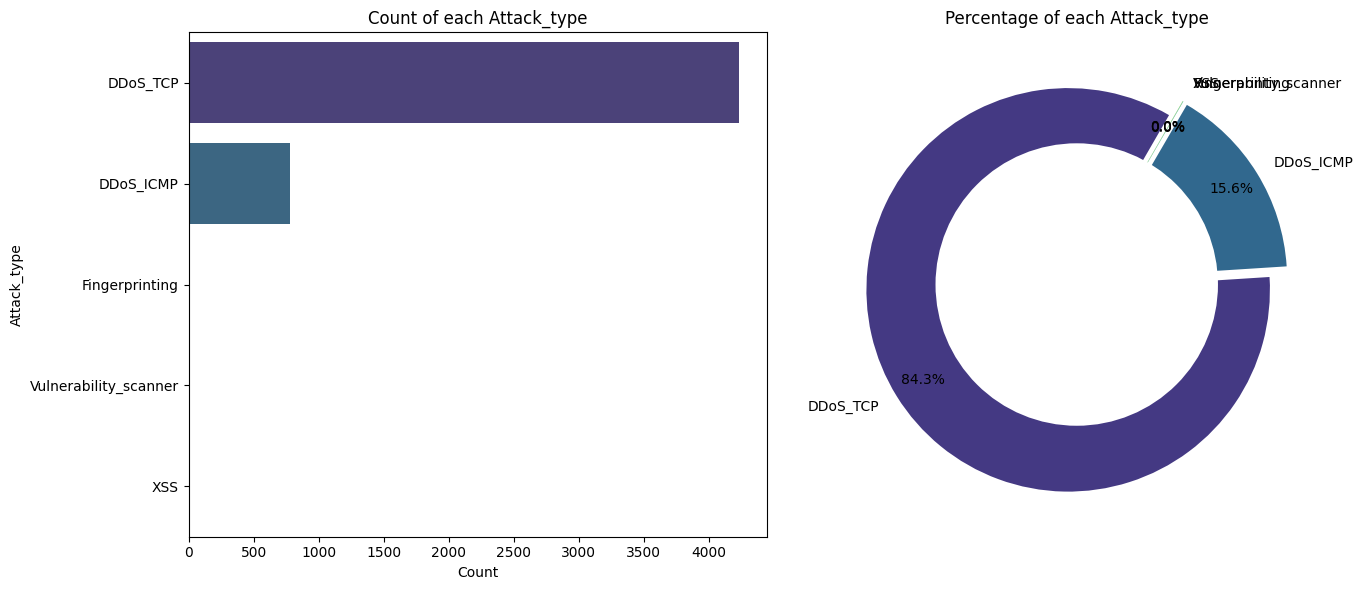

In [439]:
label_col = "Attack_type"
plot_label_distribution(df_duplicados, label_col)

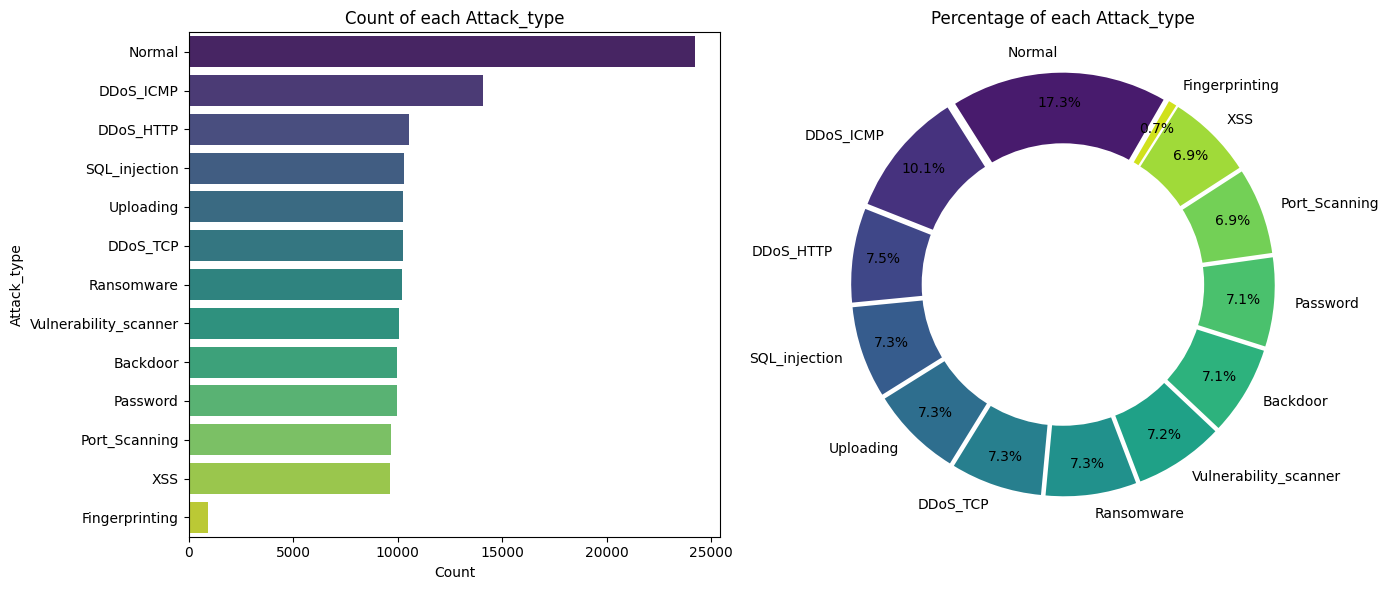

In [440]:
label_col = "Attack_type"
plot_label_distribution(df, label_col)

## 4 - Saving Data

In [441]:
pd.to_pickle(df, config['processed_path'] / f"{filename}.pkl")